In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Excel file to inspect its structure
file_path = 'Desktop/Thesis_project/Thesis_Test_ML/Cell_1_Y7.XLSX'
data = pd.read_excel(file_path)

In [3]:
# Display the first few rows of the data for exploration
data.head()

,Material Description,Movement Type Text,Posting Date,Quantity,Amount in LC
0,Top Module,GI scrapping,2024-11-29,-1.0,-1048.31
1,Top Module,GI scrapping,2024-11-29,-1.0,-1048.31
2,Top Module,GI scrapping,2024-11-13,-1.0,-1122.09
3,Top Module,GI scrapping,2024-11-12,-1.0,-1122.09
4,Top Module,GI scrapping,2024-11-11,-1.0,-1122.09


In [4]:
# Data preprocessing
# Selecting features and target variable
columns_of_interest = [
    'Quantity', 'Movement Type Text', 'Material Description', 'Amount in LC'
]
data_subset = data[columns_of_interest].dropna()



In [5]:
# Encode categorical features (Material, Movement Type)
data_subset['Material Description'] = data_subset['Material Description'].astype('category').cat.codes
data_subset['Movement Type Text'] = data_subset['Movement Type Text'].astype('category').cat.codes

In [6]:
# Split data into features (X) and target (y)
X = data_subset[['Quantity', 'Movement Type Text', 'Material Description']]
y = data_subset['Amount in LC']



In [7]:
# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train a Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [9]:
#The target variable (Amount in LC) has limited variability:
# Majority (-105.26): 53 out of 57 records.
#Other Values: -421.04 (3 occurrences) and -210.52 (1 occurrence).

In [10]:
# Predict on test data
y_pred = model.predict(X_test)

In [11]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [12]:
mae, r2 #Mean Absolute Error (MAE): Close to zero, suggesting very small prediction errors.
        #R² Score: Zero, implying that the model isn't explaining variance in the target.

(77.03486306359592, -0.18496271839815925)

In [13]:
# Inspecting the distribution of the target variable (Amount in LC)
y.describe(), y.value_counts()

(count       70.000000
 mean     -1433.797143
 std       1301.550878
 min     -12055.280000
 25%      -1331.900000
 50%      -1245.260000
 75%      -1245.260000
 max      -1048.310000
 Name: Amount in LC, dtype: float64,
 Amount in LC
 -1245.26     21
 -1331.90      5
 -1321.59      4
 -1122.09      3
 -1048.31      2
 -1334.20      2
 -1339.48      2
 -1335.78      2
 -1193.63      2
 -1331.91      1
 -1321.67      1
 -1338.98      1
 -1331.92      1
 -12055.28     1
 -2678.96      1
 -1332.75      1
 -1321.83      1
 -1357.15      1
 -1357.17      1
 -1321.72      1
 -1321.60      1
 -1321.61      1
 -1272.15      1
 -1260.57      1
 -1246.82      1
 -1245.52      1
 -1214.69      1
 -1194.84      1
 -1193.82      1
 -1193.69      1
 -1193.64      1
 -1122.27      1
 -1122.16      1
 -1122.13      1
 -1122.11      1
 -1503.45      1
 Name: count, dtype: int64)

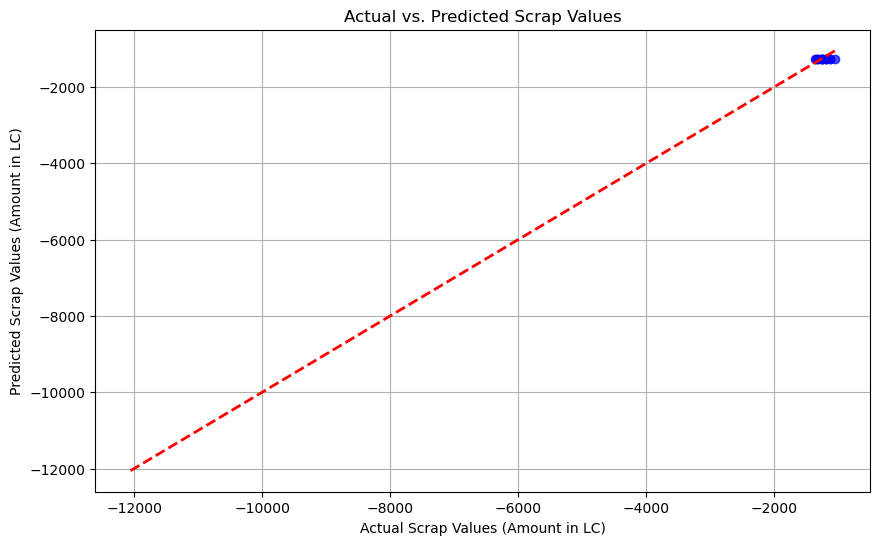

In [14]:
# Plotting Actual vs. Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)  # Ideal fit line
plt.xlabel("Actual Scrap Values (Amount in LC)")
plt.ylabel("Predicted Scrap Values (Amount in LC)")
plt.title("Actual vs. Predicted Scrap Values")
plt.grid(True)
plt.show()

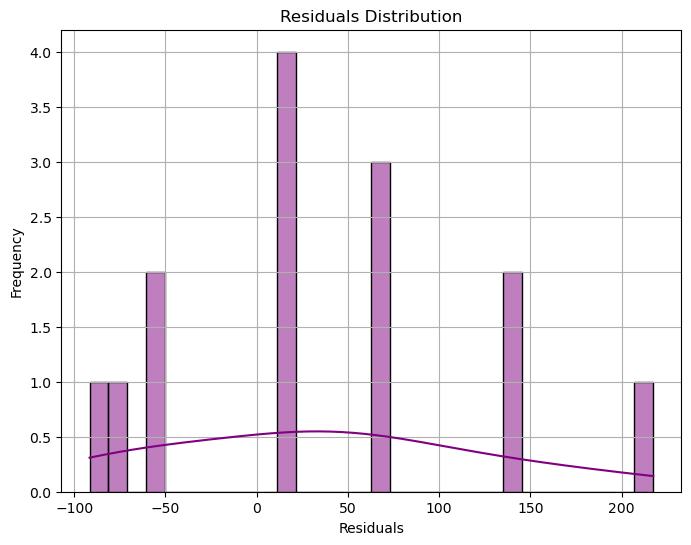

In [15]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.grid()
plt.show()